<a href="https://colab.research.google.com/github/Xiao2602/ProjetDATA/blob/main/ProjetData.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phase 1 & 2 : Audit et Nettoyage

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Chargement
df = pd.read_csv('marketcorp_sales.csv')

# 2. Nettoyage avec sauts de lignes pour la clarté
print("--- VÉRIFICATION DES MANQUANTS (AVANT) ---")
print(df.isnull().sum())
print("\n" + "="*40 + "\n") # Ligne de séparation

# Item_Weight : Remplacement par la moyenne
moyenne_poids = np.nanmean(df['Item_Weight'])
df['Item_Weight'] = df['Item_Weight'].replace(np.nan, moyenne_poids)

# Outlet_Size : Remplacement par "Inconnu"
df['Outlet_Size'] = df['Outlet_Size'].replace(np.nan, "Inconnu")

# Item_Visibility : Remplacement des 0.0 par la médiane
mediane_vis = df['Item_Visibility'].median()
df['Item_Visibility'] = df['Item_Visibility'].replace(0.0, mediane_vis)

# Item_Fat_Content : Uniformisation avec l'opérateur logique | (OU)
df['Item_Fat_Content'] = np.where(
    (df['Item_Fat_Content'] == 'low fat') | (df['Item_Fat_Content'] == 'LF'),
    'Low Fat',
    df['Item_Fat_Content']
)
df['Item_Fat_Content'] = df['Item_Fat_Content'].replace('reg', 'Regular')

print("--- VÉRIFICATION DES MANQUANTS (APRÈS) ---")
print(df.isnull().sum())
print("\n" + "="*40 + "\n")

--- VÉRIFICATION DES MANQUANTS (AVANT) ---
Item_Identifier                0
Item_Weight                  300
Item_Fat_Content               0
Item_Visibility                0
Item_Type                      0
Item_MRP                       0
Outlet_Identifier              0
Outlet_Establishment_Year      0
Outlet_Size                  509
Outlet_Location_Type           0
Outlet_Type                    0
Item_Outlet_Sales              0
dtype: int64


--- VÉRIFICATION DES MANQUANTS (APRÈS) ---
Item_Identifier              0
Item_Weight                  0
Item_Fat_Content             0
Item_Visibility              0
Item_Type                    0
Item_MRP                     0
Outlet_Identifier            0
Outlet_Establishment_Year    0
Outlet_Size                  0
Outlet_Location_Type         0
Outlet_Type                  0
Item_Outlet_Sales            0
dtype: int64




In [6]:
# 1. Item_Weight : Remplacement par la moyenne via NumPy
moyenne_poids = np.nanmean(df['Item_Weight'])
df['Item_Weight'] = df['Item_Weight'].replace(np.nan, moyenne_poids)

# 2. Outlet_Size : Remplacement des NaN par "Inconnu"
df['Outlet_Size'] = df['Outlet_Size'].replace(np.nan, "Inconnu")

# 3. Item_Visibility : Remplacement des 0.0 par la médiane
mediane_visibilite = df['Item_Visibility'].median()
df['Item_Visibility'] = df['Item_Visibility'].replace(0.0, mediane_visibilite)

# 4. Item_Fat_Content : Uniformisation des labels
# On utilise np.where pour transformer les variantes en 'Low Fat' ou 'Regular'
df['Item_Fat_Content'] = np.where(df['Item_Fat_Content'].isin(['low fat', 'LF', 'Low Fat']), 'Low Fat', 'Regular')

# Contrôle final
print("Manquants après nettoyage :\n", df.isnull().sum())

Manquants après nettoyage :
 Item_Identifier              0
Item_Weight                  0
Item_Fat_Content             0
Item_Visibility              0
Item_Type                    0
Item_MRP                     0
Outlet_Identifier            0
Outlet_Establishment_Year    0
Outlet_Size                  0
Outlet_Location_Type         0
Outlet_Type                  0
Item_Outlet_Sales            0
dtype: int64


# Phase 3 : Exploration Chiffrée

In [7]:
# 1. Describe avec espace
print("--- STATISTIQUES DES COLONNES NUMÉRIQUES ---")
print(df.describe())
print("\n" + "-"*30 + "\n")

# 2. Value Counts avec titres clairs
print("--- RÉPARTITION PAR TAILLE DE MAGASIN ---")
print(df['Outlet_Size'].value_counts())
print("\n")

print("--- RÉPARTITION PAR TYPE DE MAGASIN ---")
print(df['Outlet_Type'].value_counts())
print("\n")

print("--- RÉPARTITION PAR TYPE DE GRAS ---")
print(df['Item_Fat_Content'].value_counts())
print("\n" + "-"*30 + "\n")

# 3. Comparaison filtrée
print("--- ANALYSE COMPARATIVE DES VENTES ---")
moy_petit = df[df['Outlet_Size'] == 'Small']['Item_Outlet_Sales'].mean()
moy_grand = df[df['Outlet_Size'] == 'High']['Item_Outlet_Sales'].mean()

print(f"Ventes moyennes (Petits Magasins) : {moy_petit:.2f} €")
print(f"Ventes moyennes (Grands Magasins) : {moy_grand:.2f} €")

--- STATISTIQUES DES COLONNES NUMÉRIQUES ---
       Item_Weight  Item_Visibility     Item_MRP  Outlet_Establishment_Year  \
count  2000.000000      2000.000000  2000.000000                2000.000000   
mean     12.893839         0.088839   147.621430                1998.732500   
std       4.265468         0.059633    66.397817                   7.672769   
min       5.000186         0.001509    30.140676                1985.000000   
25%       9.565677         0.045233    90.909028                1997.000000   
50%      12.893839         0.071922   147.257228                1999.000000   
75%      16.072337         0.120100   204.616633                2004.000000   
max      20.992923         0.376628   259.970431                2009.000000   

       Item_Outlet_Sales  
count        2000.000000  
mean         2085.837866  
std          1287.183526  
min            14.585396  
25%           995.936369  
50%          1924.322705  
75%          3037.907990  
max          7453.501707  


# Phase 4 : Analyse Exploratoire (Dashboard)

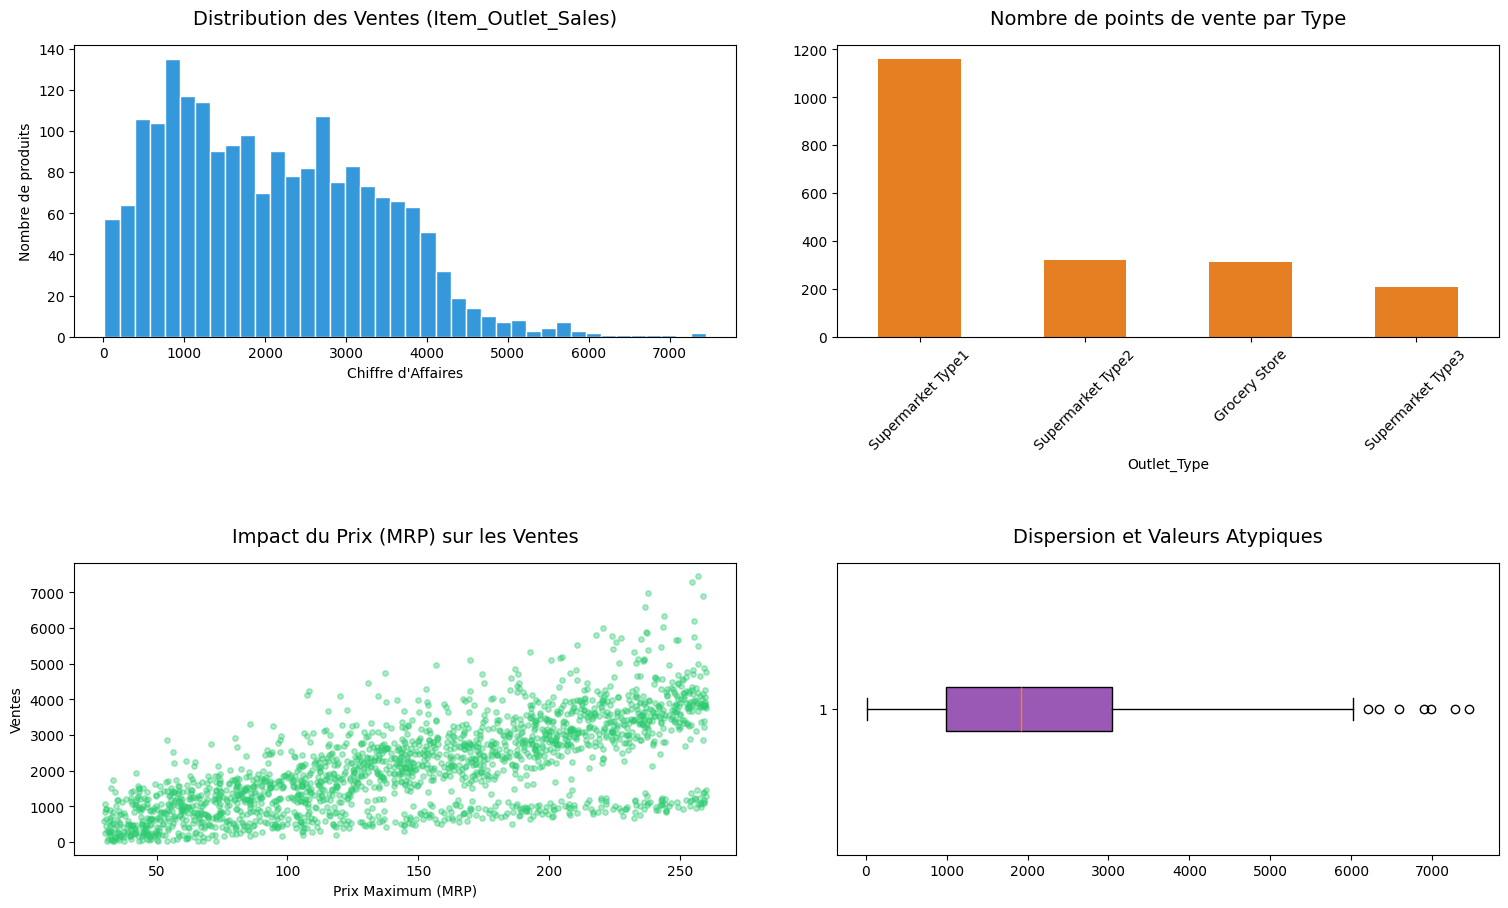

In [8]:
# On définit une taille de figure agréable
plt.figure(figsize=(16, 10))

# 1. Histogramme
plt.subplot(2, 2, 1)
plt.hist(df['Item_Outlet_Sales'], bins=40, color='#3498db', edgecolor='white')
plt.title('Distribution des Ventes (Item_Outlet_Sales)', fontsize=14, pad=15)
plt.xlabel('Chiffre d\'Affaires')
plt.ylabel('Nombre de produits')

# 2. Bar Chart
plt.subplot(2, 2, 2)
df['Outlet_Type'].value_counts().plot(kind='bar', color='#e67e22', rot=45)
plt.title('Nombre de points de vente par Type', fontsize=14, pad=15)

# 3. Scatter Plot
plt.subplot(2, 2, 3)
plt.scatter(df['Item_MRP'], df['Item_Outlet_Sales'], alpha=0.4, c='#2ecc71', s=15)
plt.title('Impact du Prix (MRP) sur les Ventes', fontsize=14, pad=15)
plt.xlabel('Prix Maximum (MRP)')
plt.ylabel('Ventes')

# 4. Boxplot
plt.subplot(2, 2, 4)
plt.boxplot(df['Item_Outlet_Sales'], vert=False, patch_artist=True,
            boxprops=dict(facecolor="#9b59b6"))
plt.title('Dispersion et Valeurs Atypiques', fontsize=14, pad=15)

# Ajout d'un espacement automatique entre les graphiques
plt.tight_layout(pad=4.0)
plt.show()

# Phase 5 : Storytelling & Recommandations

*1. Synthèse pour la Direction Régionale*


**Objet : Analyse de la performance des points de vente MarketCorp**


 L'analyse de notre réseau montre une forte corrélation entre le prix de vente (MRP) et le volume de ventes final. Nous observons une concentration importante du chiffre d'affaires sur les supermarchés de type 1, tandis que les "Grocery Stores" peinent à atteindre des seuils de rentabilité comparables.
    
Le nettoyage des données a révélé une gestion hétérogène de l'inventaire (poids manquants) et de la visibilité des produits en rayon, ce qui suggère un manque de standardisation opérationnelle entre les différentes zones géographiques.

*2. Plan d'Action Opérationnel (30 Jours)*

> Phase 1 : Standardisation & Audit (J+1 à J+7)

 Ajouter une citation


 * Action : Mise à jour du référentiel produit global.

 * Objectif : Éliminer définitivement les labels "LF", "low fat" et "reg" dans le système de gestion des stocks (ERP).

*  Livrable : Base de données produits 100% propre.

> Phase 2 : Investigation Terrain (J+8 à J+15)

*  Action : Recensement des caractéristiques des magasins marqués "Inconnu".

 * Objectif : Compléter les données de taille d'établissement pour 100% du parc.

 * Livrable : Tableau de bord de segmentation des points de vente mis à jour.

> Phase 3 : Test de Performance (J+16 à J+25)

 * Action : Campagne "Visibilité Plus" sur 10 références à fort MRP dans un échantillon de 5 magasins "Small".

 * Objectif : Mesurer si l'augmentation de la visibilité compense la petite taille du point de vente.

 * Livrable : Rapport de corrélation Visibilité/Ventes post-test.

> Phase 4 : Revue Stratégique (J+26 à J+30)

 * Action : Présentation des résultats du test à la Direction Régionale.

 * Objectif : Valider le budget pour le déploiement national des recommandations.

 * Livrable : Feuille de route pour le trimestre suivant.